# Section 18: Convolution and transformations

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader

from scipy.signal import convolve2d
import requests
import imageio.v3 as iio, io

## Convolution in code

In [2]:
image_size = 20
image = np.random.randn(image_size, image_size)

kernel_size = 7
X, Y = np.meshgrid(np.linspace(-3, 3, kernel_size), np.linspace(-3, 3, kernel_size))
kernel = np.exp(-(X ** 2 + Y ** 2) / 7)

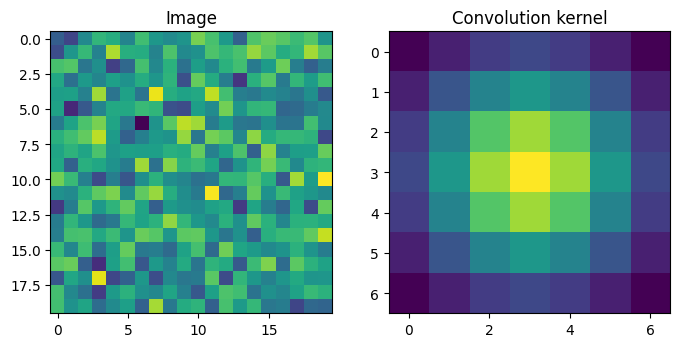

In [3]:
_, ax = plt.subplots(1, 2, figsize=(8, 6))

ax[0].imshow(image)
ax[0].set_title('Image')

ax[1].imshow(kernel)
ax[1].set_title("Convolution kernel")

plt.show()

In [4]:
conv_output = np.zeros((image_size, image_size))
half_kernel = kernel_size // 2

for i in range(half_kernel, image_size - half_kernel):
    for j in range(half_kernel, image_size - half_kernel):
        piece_of_image = image[i - half_kernel:i + half_kernel + 1, j - half_kernel: j + half_kernel + 1]
        conv_output[i, j] = np.sum(piece_of_image * kernel[::-1, ::-1])

In [5]:
conv_output_2 = convolve2d(image, kernel, mode='valid')

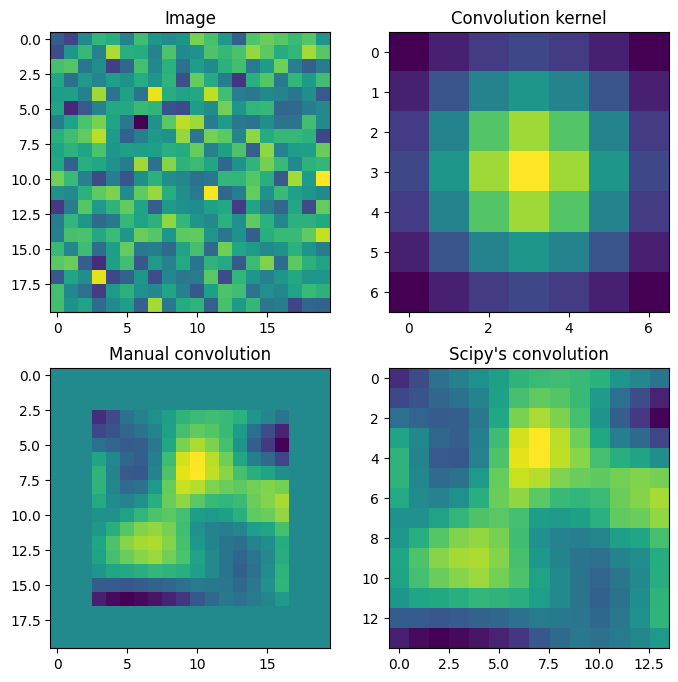

In [6]:
_, ax = plt.subplots(2, 2, figsize=(8, 8))

ax[0, 0].imshow(image)
ax[0, 0].set_title('Image')

ax[0, 1].imshow(kernel)
ax[0, 1].set_title("Convolution kernel")

ax[1, 0].imshow(conv_output)
ax[1, 0].set_title("Manual convolution")

ax[1, 1].imshow(conv_output_2)
ax[1, 1].set_title("Scipy's convolution")

plt.show()

In [7]:
url = 'https://s3-eu-west-1.amazonaws.com/production-static-stedelijk/images/_bezoek/scaled/1024/key-imagestedelijkmuseum2025cossip1web.jpg'
r = requests.get(url, headers={"User-Agent": "Mozilla/5.0 (research script; contact@example.com)"})

r.raise_for_status()

bathtub = iio.imread(io.BytesIO(r.content))

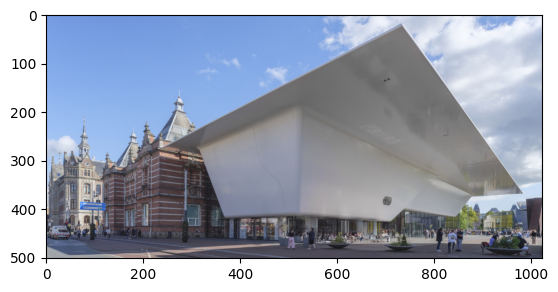

In [8]:
plt.imshow(bathtub)
plt.show()

In [9]:
print(bathtub.shape)

bathtub = np.mean(bathtub, axis=2)
bathtub = bathtub / np.max(bathtub)

print(bathtub.shape)

(502, 1024, 3)
(502, 1024)


In [10]:
vertical_kernel = np.array([
    [1, 0, -1],
    [1, 0, -1],
    [1, 0, -1]
])
horizontal_kernel = np.array([
    [1, 1, 1],
    [0, 0, 0],
    [-1, -1, -1]
])

conv_output = convolve2d(bathtub, vertical_kernel, mode='same')
conv_output_2 = convolve2d(bathtub, horizontal_kernel, mode='same')

print(conv_output.shape)
print(conv_output_2.shape)

(502, 1024)
(502, 1024)


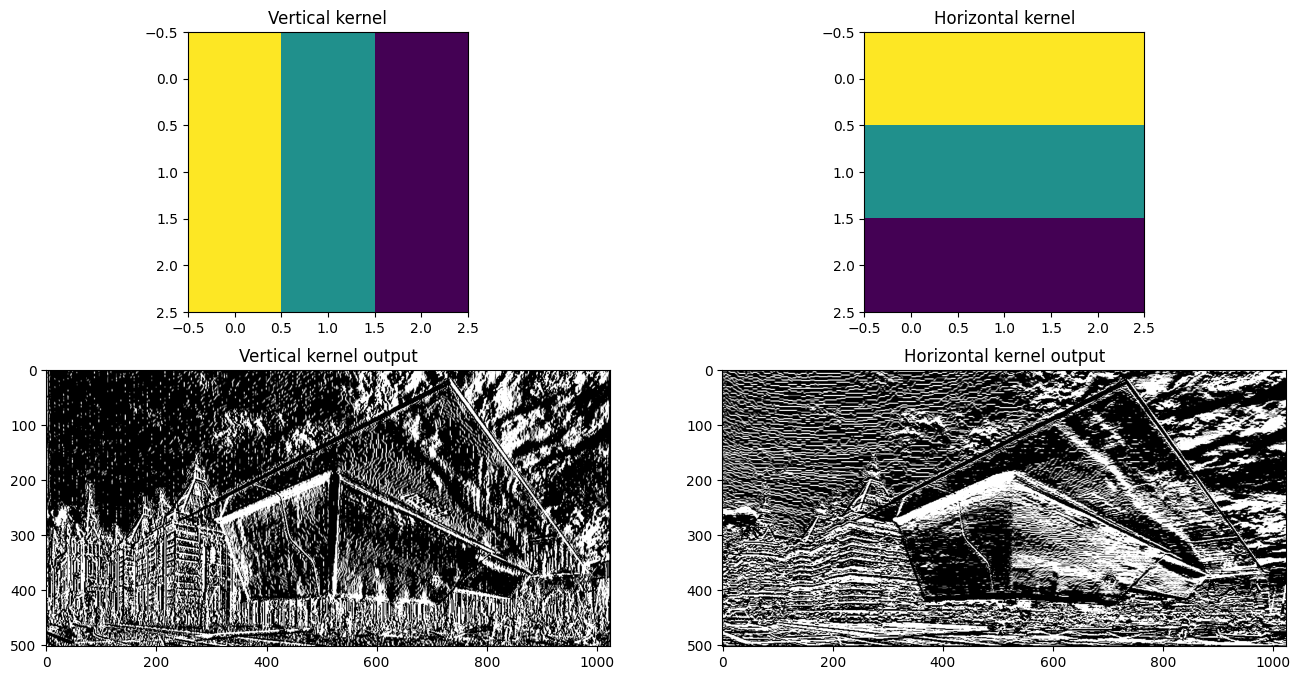

In [11]:
_, ax = plt.subplots(2, 2, figsize=(16, 8))

ax[0, 0].imshow(vertical_kernel)
ax[0, 0].set_title("Vertical kernel")

ax[0, 1].imshow(horizontal_kernel)
ax[0, 1].set_title("Horizontal kernel")

ax[1, 0].imshow(conv_output, cmap='gray', vmin=0, vmax=.01)
ax[1, 0].set_title("Vertical kernel output")

ax[1, 1].imshow(conv_output_2, cmap='gray', vmin=0, vmax=.01)
ax[1, 1].set_title("Horizontal kernel output")

plt.show()

In [12]:
vertical_kernel_t = torch.tensor(vertical_kernel).view(1, 1, 3, 3).double()
horizontal_kernel_t = torch.tensor(horizontal_kernel).view(1, 1, 3, 3).double()
bathtub_t = torch.tensor(bathtub).view(1, 1, bathtub.shape[0], bathtub.shape[1])

print(vertical_kernel_t.shape)
print(horizontal_kernel_t.shape)
print(bathtub_t.shape)

torch.Size([1, 1, 3, 3])
torch.Size([1, 1, 3, 3])
torch.Size([1, 1, 502, 1024])


In [13]:
conv_output = F.conv2d(bathtub_t, vertical_kernel_t)
conv_output_2 = F.conv2d(bathtub_t, horizontal_kernel_t)

print(conv_output.shape)
print(conv_output_2.shape)

torch.Size([1, 1, 500, 1022])
torch.Size([1, 1, 500, 1022])


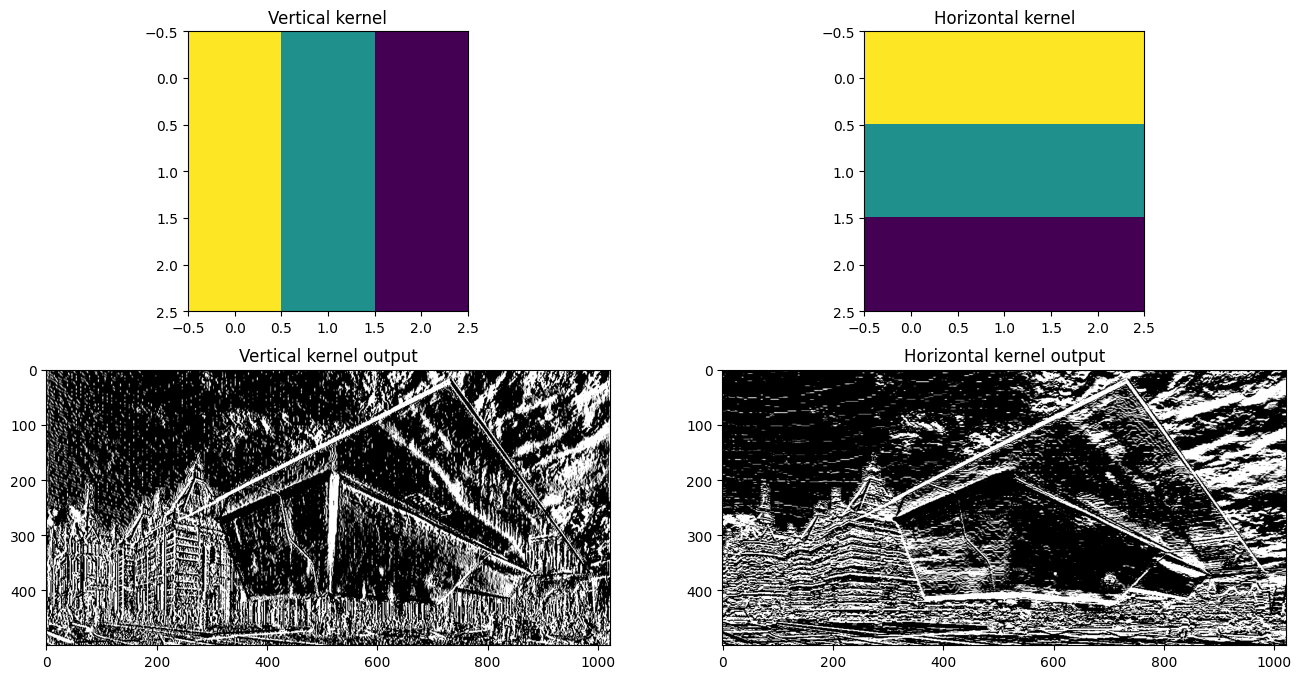

In [14]:
_, ax = plt.subplots(2, 2, figsize=(16, 8))

ax[0, 0].imshow(torch.squeeze(vertical_kernel_t.detach()))
ax[0, 0].set_title("Vertical kernel")

ax[0, 1].imshow(torch.squeeze(horizontal_kernel_t.detach()))
ax[0, 1].set_title("Horizontal kernel")

ax[1, 0].imshow(torch.squeeze(conv_output.detach()), cmap='gray', vmin=0, vmax=.01)
ax[1, 0].set_title("Vertical kernel output")

ax[1, 1].imshow(torch.squeeze(conv_output_2.detach()), cmap='gray', vmin=0, vmax=.01)
ax[1, 1].set_title("Horizontal kernel output")

plt.show()

## The Conv2 class in PyTorch

In [15]:
in_channels = 3
out_channels = 15
kernel_size = 5
stride = 1
padding = 0

c = nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding)

print(c)
print()
print(f"Size of weights: {c.weight.shape}")
print(f"Size of bias: {c.bias.shape}")

Conv2d(3, 15, kernel_size=(5, 5), stride=(1, 1))

Size of weights: torch.Size([15, 3, 5, 5])
Size of bias: torch.Size([15])


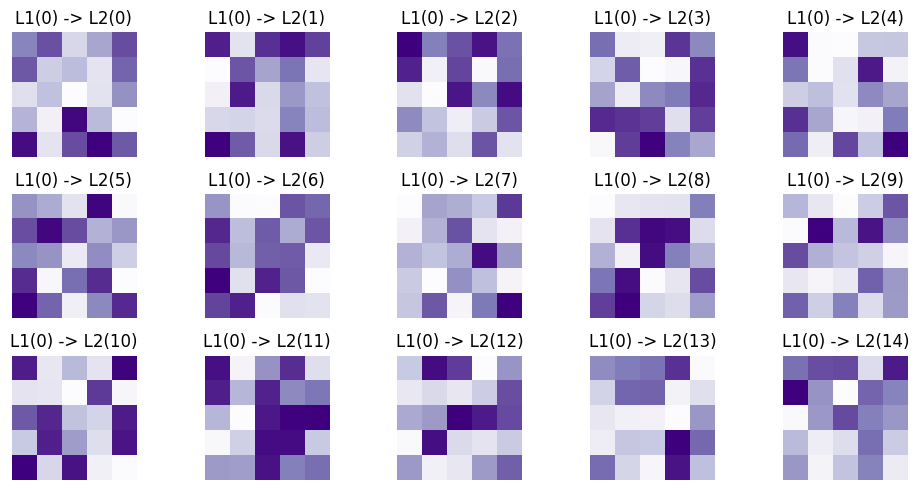

In [16]:
_, axs = plt.subplots(3, 5, figsize=(10, 5))

for i, ax in enumerate(axs.flatten()):
    ax.imshow(torch.squeeze(c.weight[i, 0, :, :]).detach(), cmap='Purples')
    ax.set_title("L1(0) -> L2(%s)" %i)
    ax.axis('off')

plt.tight_layout()
plt.show()

torch.Size([1, 3, 64, 64])
(64, 64, 3, 1)


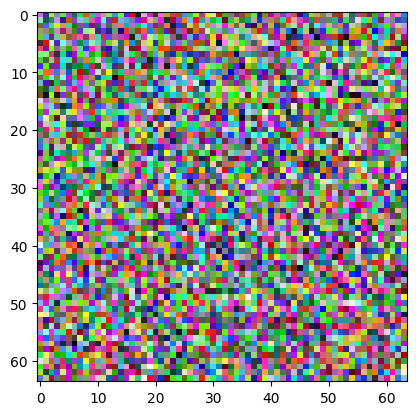

In [17]:
image_size = (1, 3, 64, 64)
image = torch.rand(image_size)
image_view = image.permute(2, 3, 1, 0).numpy()

print(image.shape)
print(image_view.shape)

plt.imshow(np.squeeze(image_view))
plt.show()

In [18]:
conv_output = c(image)

print(image.shape)
print(conv_output.shape)

torch.Size([1, 3, 64, 64])
torch.Size([1, 15, 60, 60])


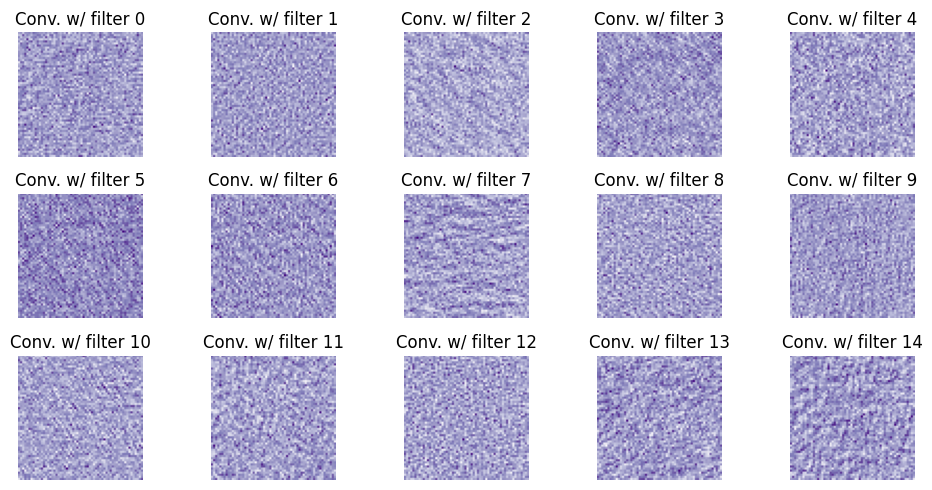

In [19]:
_, axs = plt.subplots(3, 5, figsize=(10, 5))

for i, ax in enumerate(axs.flatten()):
    I = torch.squeeze(conv_output[0, i, :, :]).detach()

    ax.imshow(I, cmap='Purples')
    ax.set_title("Conv. w/ filter %s" %i)
    ax.axis('off')

plt.tight_layout()
plt.show()

## CodeChallenge: Choose the parameters

In [20]:
def convolve_image(in_channels_param, image_size_param, out_channels_param, kernel_size_param, stride_param, padding_param):
    c_local = nn.Conv2d(in_channels_param, out_channels_param, kernel_size_param, stride_param, padding_param)
    image_local = torch.rand(1, in_channels_param, image_size_param[0], image_size_param[1])
    conv_output_local = c_local(image_local)

    empirical_size_local = torch.squeeze(conv_output_local).shape
    expected_size_local = np.array([out_channels_param, 0, 0], dtype=int)
    expected_size_local[1] = np.floor((image_size_param[0] + (2 * padding_param) - kernel_size_param) / stride_param[0]) + 1
    expected_size_local[2] = np.floor((image_size_param[1] + (2 * padding_param) - kernel_size_param) / stride_param[1]) + 1

    print(f"Expected size: {expected_size_local}")
    print(f"Empirical size: {list(empirical_size_local)}")

In [21]:
# Convolve an image of size 1x256x256 to produce a 1x252x84 result.
in_channels = 1
image_size = [256, 256]
out_channels = 1
kernel_size = 7
stride = (1, 3)
padding = 1

convolve_image(in_channels, image_size, out_channels, kernel_size, stride, padding)

Expected size: [  1 252  84]
Empirical size: [252, 84]


In [22]:
# Convolve an image of size 3x64x64 to produce a 10x28x28 result.
in_channels = 3
image_size = [64, 64]
out_channels = 10
kernel_size = 9
stride = (2, 2)
padding = 0

convolve_image(in_channels, image_size, out_channels, kernel_size, stride, padding)

Expected size: [10 28 28]
Empirical size: [10, 28, 28]


In [23]:
# Convolve an image of size 3x196x96 to produce a 5x66x49 result.
in_channels = 3
image_size = [196, 96]
out_channels = 5
kernel_size = 5
stride =(3, 2)
padding = 3

convolve_image(in_channels, image_size, out_channels, kernel_size, stride, padding)

Expected size: [ 5 66 49]
Empirical size: [5, 66, 49]


In [24]:
# Convolve an image of size 1x32x32 to produce a 6x28x28 result.
in_channels = 1
image_size = [32, 32]
out_channels = 6
kernel_size = 5
stride = (1, 1)
padding = 0

convolve_image(in_channels, image_size, out_channels, kernel_size, stride, padding)

Expected size: [ 6 28 28]
Empirical size: [6, 28, 28]


In [25]:
# Convolve an image of size 3x227x227 to produce a 96x55x55 result.
in_channels = 3
image_size = [227, 227]
out_channels = 96
kernel_size = 11
stride = (4, 4)
padding = 1

convolve_image(in_channels, image_size, out_channels, kernel_size, stride, padding)

Expected size: [96 55 55]
Empirical size: [96, 55, 55]


In [26]:
# Convolve an image of size 3x224x224 to produce a 64x224x224 result.
in_channels = 3
image_size = [224, 224]
out_channels = 64
kernel_size = 3
stride = (1, 1)
padding = 1

convolve_image(in_channels, image_size, out_channels, kernel_size, stride, padding)

Expected size: [ 64 224 224]
Empirical size: [64, 224, 224]


## Transpose convolution

In [27]:
in_channels = 3
out_channels = 15
kernel_size = 5
stride = 1
padding = 0

c = nn.ConvTranspose2d(in_channels, out_channels, kernel_size, stride, padding)

print(c)
print()
print(f"Size of weights: {c.weight.shape}")
print(f"Size of bias: {c.bias.shape}")

ConvTranspose2d(3, 15, kernel_size=(5, 5), stride=(1, 1))

Size of weights: torch.Size([3, 15, 5, 5])
Size of bias: torch.Size([15])


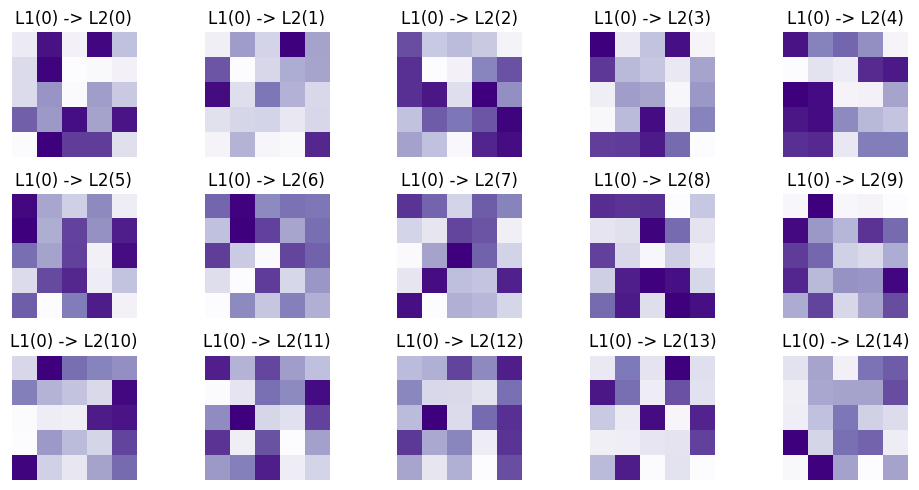

In [28]:
_, axs = plt.subplots(3, 5, figsize=(10, 5))

for i, ax in enumerate(axs.flatten()):
    ax.imshow(torch.squeeze(c.weight[0, i, :, :]).detach(), cmap='Purples')
    ax.set_title("L1(0) -> L2(%s)" %i)
    ax.axis('off')

plt.tight_layout()
plt.show()

torch.Size([1, 3, 64, 64])
(64, 64, 3, 1)


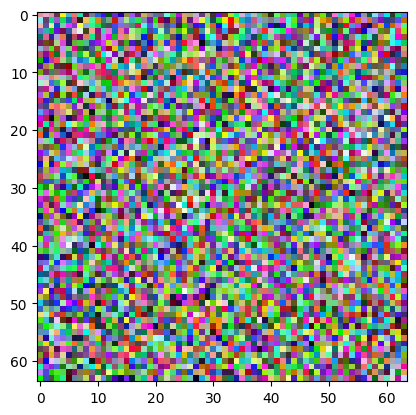

In [29]:
image_size = (1, 3, 64, 64)
image = torch.rand(image_size)
image_view = image.permute(2, 3, 1, 0).numpy()

print(image.shape)
print(image_view.shape)

plt.imshow(np.squeeze(image_view))
plt.show()

In [30]:
conv_output = c(image)

print(image.shape)
print(conv_output.shape)

torch.Size([1, 3, 64, 64])
torch.Size([1, 15, 68, 68])


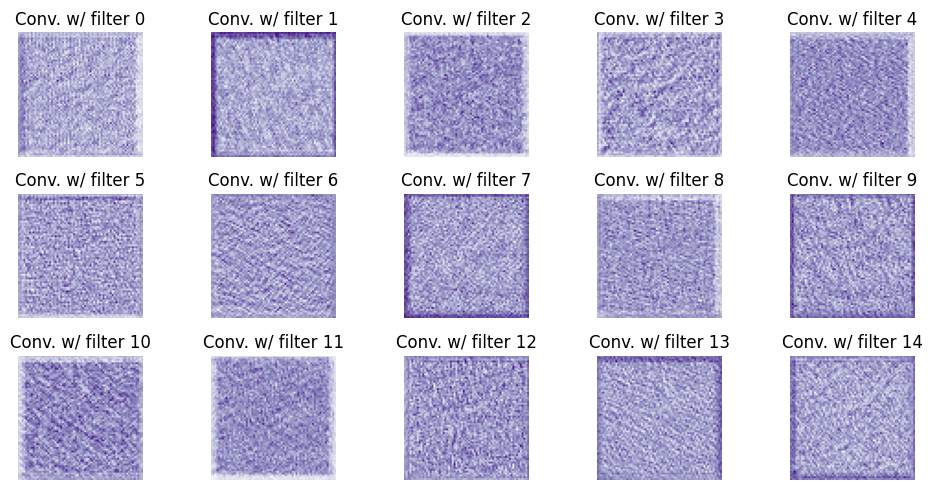

In [31]:
_, axs = plt.subplots(3, 5, figsize=(10, 5))

for i, ax in enumerate(axs.flatten()):
    I = torch.squeeze(conv_output[0, i, :, :]).detach()

    ax.imshow(I, cmap='Purples')
    ax.set_title("Conv. w/ filter %s" %i)
    ax.axis('off')

plt.tight_layout()
plt.show()

## Pooling in PyTorch

In [32]:
pool_size = 3
stride = 3

p2 = nn.MaxPool2d(pool_size, stride)
p3 = nn.MaxPool3d(pool_size, stride)

print(p2)
print(p3)

MaxPool2d(kernel_size=3, stride=3, padding=0, dilation=1, ceil_mode=False)
MaxPool3d(kernel_size=3, stride=3, padding=0, dilation=1, ceil_mode=False)


In [33]:
image_2d = torch.randn(1, 1, 30, 30)
image_3d = torch.randn(1, 3, 30, 30)

image_2d_p2 = p2(image_2d)
image_3d_p2 = p2(image_3d)
image_3d_p3 = p3(image_3d)

print(f"2D Image, 2D MaxPool: {image_2d_p2.shape}")
print(f"3D Image, 2D MaxPool: {image_3d_p2.shape}")
print(f"3D Image, 3D MaxPool: {image_3d_p3.shape}")

2D Image, 2D MaxPool: torch.Size([1, 1, 10, 10])
3D Image, 2D MaxPool: torch.Size([1, 3, 10, 10])
3D Image, 3D MaxPool: torch.Size([1, 1, 10, 10])


In [34]:
cnn_net = nn.Sequential(
    nn.Conv2d(3, 10, 5, 3, 2),
    nn.ReLU(),
    nn.AvgPool3d(3, 3),
    nn.Flatten(),
    nn.Linear(588, 1),
    nn.Sigmoid()
)

In [35]:
image = torch.rand(1, 3, 128, 128)

cnn_net(image)

tensor([[0.4706]], grad_fn=<SigmoidBackward0>)

## Image transforms

In [36]:
cifar10 = torchvision.datasets.CIFAR10(root='cifar10', download=True)

print(cifar10)

Dataset CIFAR10
    Number of datapoints: 50000
    Root location: cifar10
    Split: Train


In [37]:
print(cifar10.data.shape)
print(cifar10.classes)
print(len(cifar10.targets))

(50000, 32, 32, 3)
['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
50000


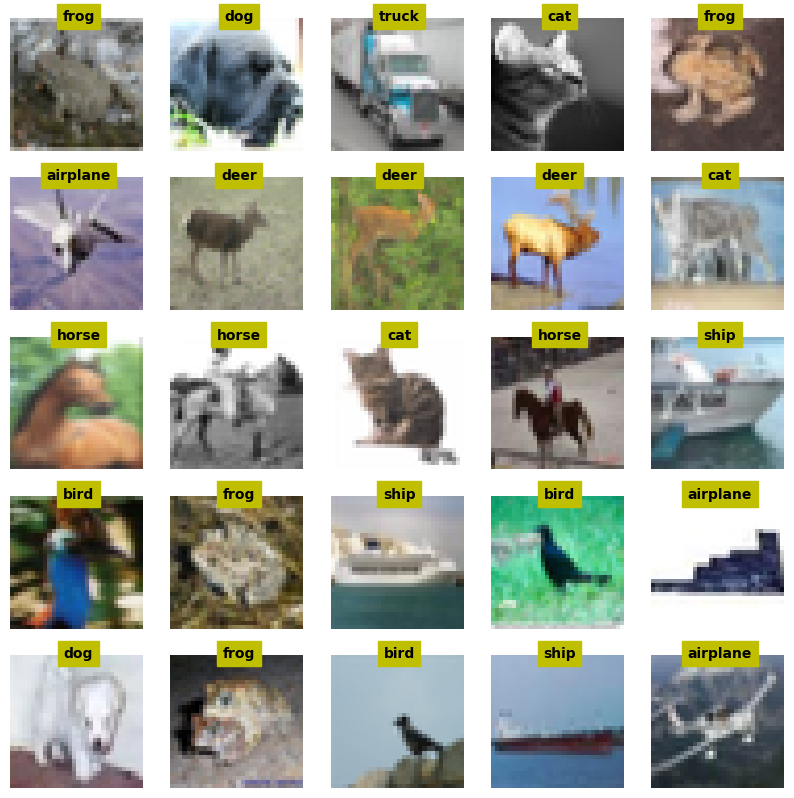

In [38]:
_, axs = plt.subplots(5, 5, figsize=(10, 10))

for ax in axs.flatten():
    random_index = np.random.choice(len(cifar10.targets))
    image = cifar10.data[random_index, :, :, :]
    label = cifar10.classes[cifar10.targets[random_index]]
    
    ax.imshow(image)
    ax.text(16, 0, label, ha='center', fontweight='bold', color='k', backgroundcolor='y')
    ax.axis('off')

In [39]:
transform = T.Compose([
    T.ToTensor(),
    T.Resize(32 * 4),
    T.Grayscale(num_output_channels=1)
])

cifar10.transform = transform

print(cifar10.data[123, :, :, :].shape)

(32, 32, 3)


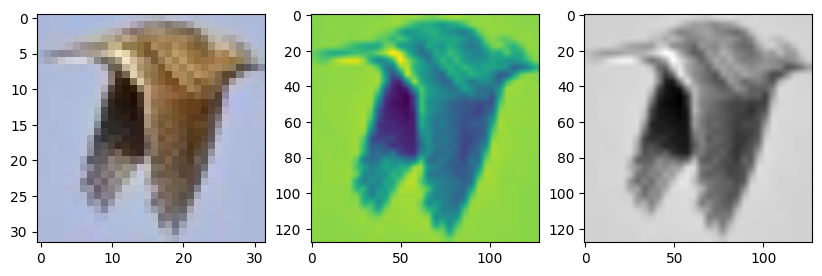

In [40]:
image_1 = transform(cifar10.data[123, :, :, :])
image_2 = cifar10.transform(cifar10.data[123, :, :, :])

_, ax = plt.subplots(1, 3, figsize=(10, 3))

ax[0].imshow(cifar10.data[123, :, :, :])
ax[1].imshow(torch.squeeze(image_1))
ax[2].imshow(torch.squeeze(image_2), cmap='gray')

plt.show()

## Creating and using custom DataLoaders

In [41]:
data = np.loadtxt(open('mnist_train_small.csv', 'rb'), delimiter=',')

data = data[:8, 1:]
labels = data[:8, 0]

data_norm = data / np.max(data)
data_norm = data_norm.reshape(data_norm.shape[0], 1, 28, 28)

print(data_norm.shape)
print(labels.shape)

data_t = torch.tensor(data_norm).float()
labels_t = torch.tensor(labels).long()

(8, 1, 28, 28)
(8,)


In [42]:
class CustomDataset(Dataset):
    def __init__(self, tensors_param, transform_param=None):
        self.tensors = tensors_param
        self.transform = transform_param
        
    def __getitem__(self, index):
        if self.transform:
            x_local = self.transform(self.tensors[0][index])
        else:
            x_local = self.tensors[0][index]
        
        y_local = self.tensors[1][index]
        
        return x_local, y_local
    
    def __len__(self):
        return self.tensors[0].size(0)

In [43]:
transform = T.Compose([
    T.ToPILImage(),
    T.RandomVerticalFlip(p=.5),
    T.ToTensor()
])

In [44]:
train_data = CustomDataset((data_t, labels_t), transform)
data_loader = DataLoader(train_data, batch_size=8, shuffle=False)

print(type(train_data))

<class '__main__.CustomDataset'>


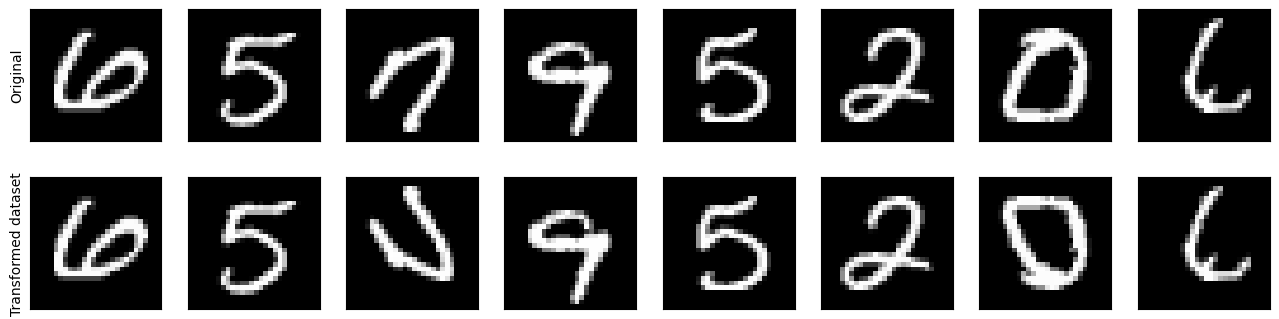

In [45]:
X, y = next(iter(data_loader))

_, axs = plt.subplots(2, 8, figsize=(16, 4))

for i in range(8):
    axs[0, i].imshow(data_t[i, 0, :, :].detach(), cmap='gray')
    axs[1, i].imshow(X[i, 0, :, :].detach(), cmap='gray')
    
    for row in range(2):
        axs[row, i].set_xticks([])
        axs[row, i].set_yticks([])
        
axs[0, 0].set_ylabel('Original')
axs[1, 0].set_ylabel("Transformed dataset")

plt.show()

In [46]:
len(train_data)

8